In [2]:
pip install --upgrade \ git+ssh://git@labdev.colibri-quantum.com/colibritd-rd/landscape_characterization.git

  Cloning ssh://****@labdev.colibri-quantum.com/colibritd-rd/landscape_characterization.git to /tmp/pip-req-build-wkuqcpe_
  Running command git clone --filter=blob:none --quiet 'ssh://****@labdev.colibri-quantum.com/colibritd-rd/landscape_characterization.git' /tmp/pip-req-build-wkuqcpe_
  Resolved ssh://****@labdev.colibri-quantum.com/colibritd-rd/landscape_characterization.git to commit 57374621d3fea3d738a48b845c6b593026191f85
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports

In [11]:
from landscape_characterization import barren_plateaus as bp
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Pauli

# Example of a problem

## Probability distribution

In [ ]:
def get_prob_distribution(params, ansatz, theta_params):

    param_dict = dict(zip(theta_params, params))                                
    # param_dict = {
    #     θ0: 0.5,
    #     θ1: 1.2
    # }

    bound_circuit = ansatz.assign_parameters(param_dict, inplace=False)

    state = Statevector.from_instruction(bound_circuit)
    probs = state.probabilities()

    return np.asarray(probs, dtype=float)

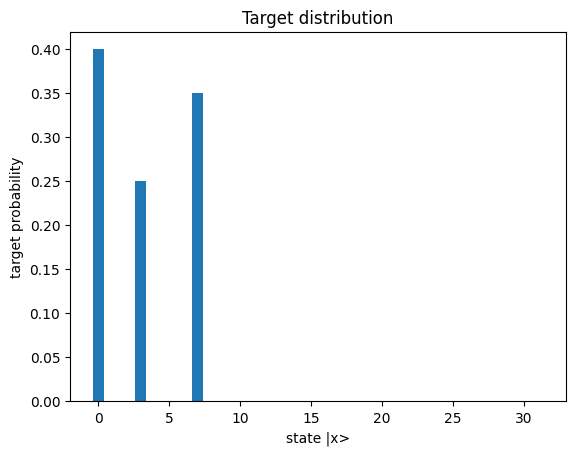

In [58]:
n_qubits = 5
dim = 2 ** n_qubits

p_target = np.zeros(dim)

# index 0 -> |000>, index 1 -> |001>, ..., index 7 -> |111>
p_target[0] = 0.40  # |000>
p_target[3] = 0.25  # |011>
p_target[7] = 0.35  # |111>

p_target = p_target / p_target.sum()    # normalize to ensure probabilities sum to 1

plt.bar(range(dim), p_target)
plt.xlabel("state |x>")
plt.ylabel("target probability")
plt.title("Target distribution")
plt.show()

## Quantum circuit

In [59]:
def build_hea_ansatz(n_qubits, n_layers, Ansatz):
    """
    Hardware Efficient Ansatz :
    - RY + RZ on each qubit
    - CNOT chain
    """
    qc = QuantumCircuit(n_qubits)

    n_params = 2 * n_qubits * n_layers
    theta = ParameterVector("θ", n_params)

    k = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(theta[k], q)
            k += 1
            qc.rz(theta[k], q)
            k += 1

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)

    qc.metadata = {"parameters": theta, "ansatz_name": Ansatz,}

    return qc

In [ ]:
def generate_params_hea(n_qubits, n_layers):
    """
    Generate random parameters for HEA ansatz (uniform distribution).
    """

    n_params = 2 * n_qubits * n_layers
    params = np.random.uniform(0, 2 * np.pi, n_params)

    return params

Number of parameters: 20


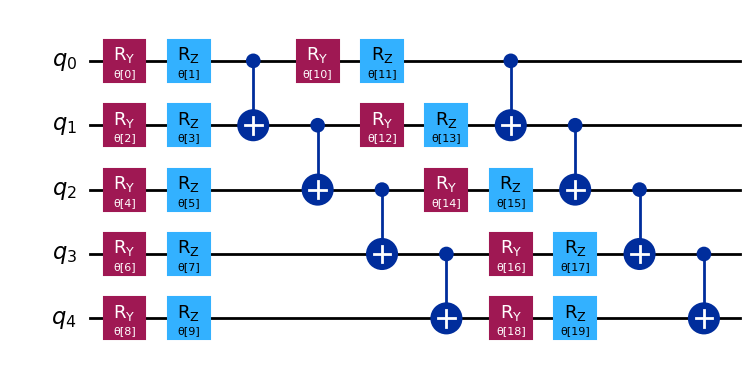

In [61]:
n_layers = 2

ansatz = build_hea_ansatz(n_qubits, n_layers, "HEA_test")
theta_params = ansatz.metadata["parameters"]

n_params = len(theta_params)

print("Number of parameters:", n_params)
ansatz.draw("mpl")

## Loss function

In [63]:
def mse_loss(params, ansatz, theta_params, p_target):
    p_model = get_prob_distribution(params, ansatz, theta_params)
    return np.sum((p_model - p_target) ** 2)

In [64]:
def circuit_mse_loss_builder(
    context,
    target="uniform",
):
    from qiskit.quantum_info import Statevector

    circuit = context["circuits"]
    n_qubits = context["n_qubits"]

    if circuit.metadata is not None and "parameters" in circuit.metadata:
        parameters = circuit.metadata["parameters"]
    else:
        parameters = list(circuit.parameters)

    dim = 2 ** n_qubits

    if target == "zero":
        p_target = np.zeros(dim)
        p_target[0] = 1.0

    elif target == "uniform":
        p_target = np.ones(dim) / dim

    else:
        raise ValueError("target must be either 'zero' or 'uniform'.")

    def loss(theta):
        theta = np.asarray(theta, dtype=float)

        bound_circuit = circuit.assign_parameters(
            dict(zip(parameters, theta)),
            inplace=False,
        )

        probs = Statevector.from_instruction(bound_circuit).probabilities()

        value = np.sum((probs - p_target) ** 2)

        return float(value)

    return loss

# Barren Plateaus Analysis

In [65]:
experiment1 = bp.ExperimentConfig(
    analysis_type="layerwise_qubits_padding",
    N_qubits=[2,4,6,8],
    N_layers=[5,8],
    Ansatz="HEA_test",
    initial_Pauli_string= Pauli('IZ'),
    padding_types=["I","linear_half"],
)

experiment2 = bp.ExperimentConfig(
    analysis_type="joint_scaling_padding",
    N_qubits=[2,4,6,8],
    N_layers=[2,4,8],
    Ansatz="HEA_test",
    initial_Pauli_string=Pauli('IZ'),
    padding_types=["log"],
)

sampling = bp.SamplingConfig(
    bootstrap_B=500,
    rel_err_target=0.05,
    N_max=20000,
)

execution = bp.ExecutionConfig(
    verbose=True,
    n_jobs=8
)

--------------------
Number of qubits: 2
Number of layers: 5
Padding type: I
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 6.42%
[Adaptive sampling] Adding 883 samples (N: 900 -> 1783)


[Adaptive sampling] N = 1783 | relative error = 4.85%
[Adaptive sampling] Target reached with N_samples = 1783 (relative error target reached)
var = 0.011377427620634957
--------------------
Number of qubits: 4
Number of layers: 5
Padding type: I
Pauli string: IIIZ


[Adaptive sampling] N = 900 | relative error = 7.37%
[Adaptive sampling] Adding 1447 samples (N: 900 -> 2347)


[Adaptive sampling] N = 2347 | relative error = 5.49%
[Adaptive sampling] Adding 1046 samples (N: 2347 -> 3393)


...

[Adaptive sampling] N = 900 | relative error = 5.79%
[Adaptive sampling] Adding 549 samples (N: 900 -> 1449)


[Adaptive sampling] N = 1449 | relative error = 5.37%
[Adaptive sampling] Adding 555 samples (N: 1449 -> 2004)


[Adaptive sampling] N = 2004 | relative error = 6.14%
[Adaptive sampling] Adding 1619 samples (N: 2004 -> 3623)


[Adaptive sampling] N = 3623 | relative error = 5.50%
[Adaptive sampling] Adding 1645 samples (N: 3623 -> 5268)


[Adaptive sampling] N = 5268 | relative error = 4.19%
[Adaptive sampling] Target reached with N_samples = 5268 (relative error target reached)
var = 4.879257568172043e-07


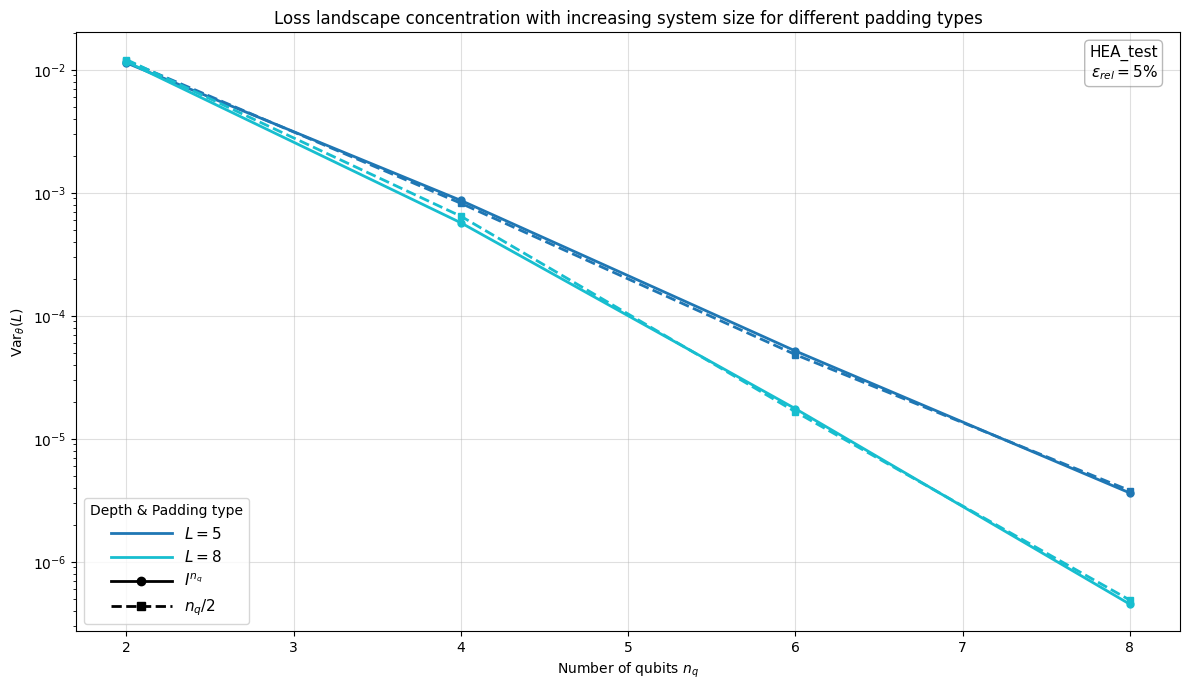

In [66]:
result1 = bp.barren_plateaus_analysis(
    experiment=experiment1,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)

--------------------
Number of qubits: 2
Number of layers: 2
Padding type: log
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 5.61%
[Adaptive sampling] Adding 460 samples (N: 900 -> 1360)


[Adaptive sampling] N = 1360 | relative error = 4.58%
[Adaptive sampling] Target reached with N_samples = 1360 (relative error target reached)
var = 0.018444809551118248
--------------------
Number of qubits: 4
Number of layers: 4
Padding type: log
Pauli string: IZIZ


[Adaptive sampling] N = 900 | relative error = 9.90%
[Adaptive sampling] Adding 3333 samples (N: 900 -> 4233)


[Adaptive sampling] N = 4233 | relative error = 4.41%
[Adaptive sampling] Target reached with N_samples = 4233 (relative error target reached)
var = 0.0012025722192133324
--------------------
Number of qubits: 6
Number of layers: 8
Padding type: log
Pauli string: IIZZIZ


...

[Adaptive sampling] N = 2324 | relative error = 7.68%
[Adaptive sampling] Adding 4260 samples (N: 2324 -> 6584)


[Adaptive sampling] N = 6584 | relative error = 3.91%
[Adaptive sampling] Target reached with N_samples = 6584 (relative error target reached)
var = 1.63261132928071e-05
--------------------
Number of qubits: 8
Number of layers: 8
Padding type: log
Pauli string: IIIIZZIZ


[Adaptive sampling] N = 900 | relative error = 9.17%
[Adaptive sampling] Adding 2730 samples (N: 900 -> 3630)


[Adaptive sampling] N = 3630 | relative error = 5.57%
[Adaptive sampling] Adding 1768 samples (N: 3630 -> 5398)


[Adaptive sampling] N = 5398 | relative error = 4.16%
[Adaptive sampling] Target reached with N_samples = 5398 (relative error target reached)
var = 4.802446803583845e-07


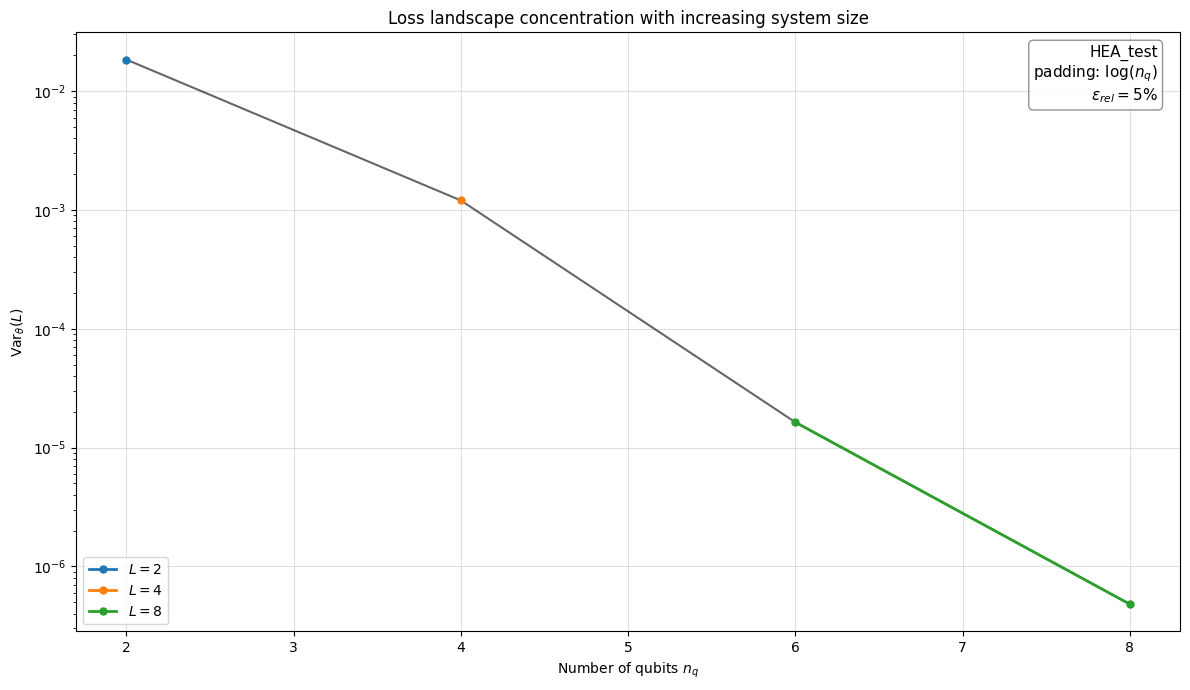

In [67]:
result2 = bp.barren_plateaus_analysis(
    experiment=experiment2,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)